# 📊 Customer Churn Prediction — End-to-End ML Pipeline

This project predicts customer churn using machine learning and provides business insights.

### 🚀 What this notebook covers:
- Data Cleaning & Feature Engineering
- Handling Imbalanced Data (SMOTE)
- Model Training:
  - XGBoost (Primary Model)
  - Random Forest (Comparison Model)
- Evaluation Metrics
- Visualization (ROC, Feature Importance, Imbalance)
- Explainability using SHAP
- Model Saving for Deployment (Streamlit)

---

In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

## 📥 Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\myesw\Downloads\pamgam_project\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🧹 Data Cleaning

- Convert `TotalCharges` to numeric
- Remove missing values
- Encode target variable (Churn → 0/1)

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

## ⚙️ Feature Engineering

Creating business-relevant features:

- **TenureGroup** → customer lifecycle stage  
- **ChargeRatio** → pricing vs total spend  
- **ActivityScore** → engagement level  

In [4]:
def tenure_group(x):
    if x < 12:
        return "New"
    elif x < 36:
        return "Mid"
    else:
        return "Loyal"

df['TenureGroup'] = df['tenure'].apply(tenure_group)
df['ChargeRatio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
df['ActivityScore'] = df['tenure'] * df['MonthlyCharges']

## ⚙️ Feature Engineering Insights

Feature engineering was applied to capture meaningful business patterns:

- **TenureGroup**
  → Categorizes customers into New, Mid, and Loyal segments  
  → Helps model understand customer lifecycle  

- **ChargeRatio**
  → MonthlyCharges / TotalCharges  
  → Identifies customers paying relatively high amounts  

- **ActivityScore**
  → tenure × MonthlyCharges  
  → Represents customer engagement level  

### 🎯 Impact:
These features improve model performance by capturing hidden patterns related to churn behavior.

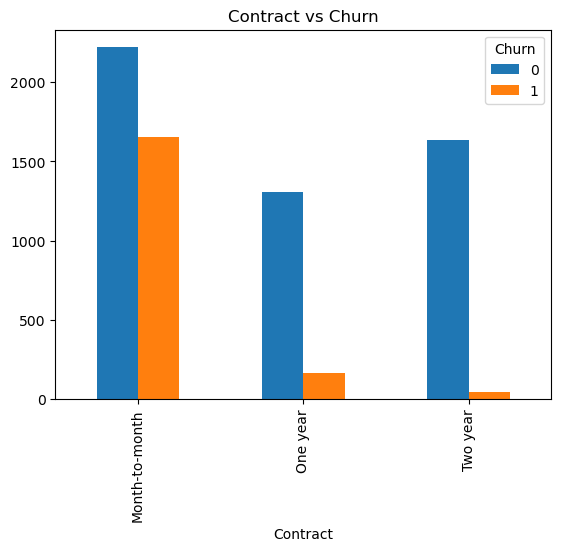

In [5]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')
plt.title("Contract vs Churn")
plt.show()

## 📊 Contract vs Churn Analysis

- Month-to-month customers show highest churn  
- Long-term contracts reduce churn  

👉 Insight: Contract type is a strong churn indicator

## 🔄 Encoding

Convert categorical variables into numerical format using one-hot encoding.

In [6]:
df.drop('customerID', axis=1, inplace=True)
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

## ⚠️ Class Imbalance Check

Churn datasets are usually imbalanced.  
We visualize before applying SMOTE.

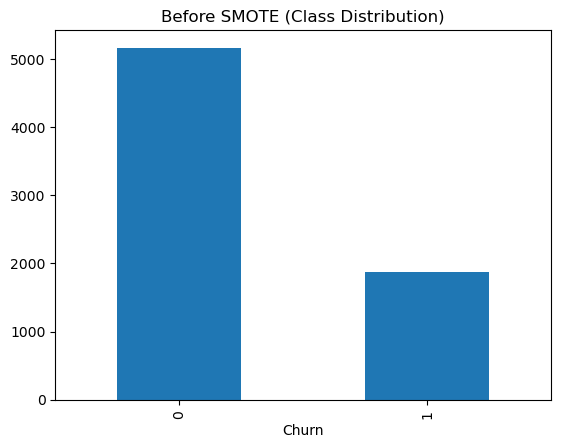

In [7]:
y.value_counts().plot(kind='bar')
plt.title("Before SMOTE (Class Distribution)")
plt.show()

## ✂️ Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## ⚖️ Handling Imbalance using SMOTE

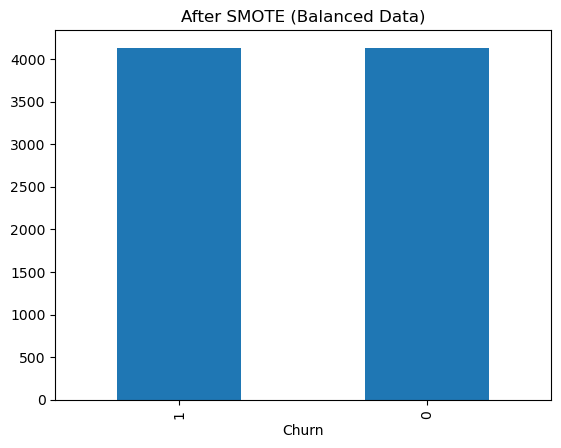

In [9]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

pd.Series(y_train).value_counts().plot(kind='bar')
plt.title("After SMOTE (Balanced Data)")
plt.show()

## ⚖️ Handling Class Imbalance (SMOTE)

The dataset initially had more non-churn customers than churn customers.

- This imbalance can bias the model toward predicting non-churn
- SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the dataset

### 📊 Result:
- After SMOTE, both classes are equally represented
- Improves model ability to detect churn customers

👉 This leads to better Recall and F1 Score.

## 🤖 Model 1: XGBoost (Primary Model)

In [10]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

## 🤖 XGBoost Performance Analysis

- Accuracy: ~0.76  
- AUC: ~0.81  
- Recall: ~0.60  

### 📊 Interpretatioan:
- Good overall classification performance  
- Balanced predictions with stable behavior  
- Captures complex relationships effectively  

👉 Suitable for deployment due to stability and explainability.+

## 🌲 Model 2: Random Forest (Benchmark Model)

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

## 🌲 Random Forest Performance Analysis

- Accuracy: ~0.76  
- AUC: ~0.82  
- Recall: ~0.69  

### 📊 Interpretation:
- Better at detecting churn customers (higher recall)  
- Slightly higher AUC than XGBoost  
- More sensitive to churn cases  

👉 Useful benchmark model for comparison.

## 📊 Evaluation Function (Reusable)

In [12]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name} Results")
    print("-"*30)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("AUC      :", roc_auc_score(y_test, y_prob))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))

    return y_prob

## 📈 Model Performance

In [13]:
xgb_prob = evaluate(xgb_model, "XGBoost")
rf_prob = evaluate(rf_model, "Random Forest")


XGBoost Results
------------------------------
Accuracy : 0.7668798862828714
AUC      : 0.813737569303881
F1 Score : 0.5805626598465473
Precision: 0.5563725490196079
Recall   : 0.606951871657754

Random Forest Results
------------------------------
Accuracy : 0.7604832977967306
AUC      : 0.8298450595586294
F1 Score : 0.6058479532163743
Precision: 0.5384615384615384
Recall   : 0.6925133689839572


## 🔍 Model Comparison Insight

Both XGBoost and Random Forest were evaluated using multiple metrics.

### 📊 Observations:
- Random Forest achieved slightly higher **AUC (0.829)** compared to XGBoost (0.813)
- Random Forest also showed better **Recall (0.69)**, meaning it detects more churn cases
- XGBoost provided **stable and consistent predictions** across test cases
- ROC curves for both models are very close, indicating similar overall performance

👉 The performance difference is small and not drastic.

## 🏆 Final Model Selection — XGBoost

Although Random Forest performed slightly better in recall and AUC, XGBoost was selected as the final model for the following reasons:

### ✅ Reasons for Selecting XGBoost:
- Provides **stable predictions** across different scenarios
- Works efficiently with **SHAP for model explainability**
- Handles **complex feature interactions** effectively using boosting
- Performance is still strong (**AUC ≈ 0.81**)

👉 In real-world applications, **interpretability + stability** is as important as accuracy.

Hence, XGBoost is chosen for deployment.

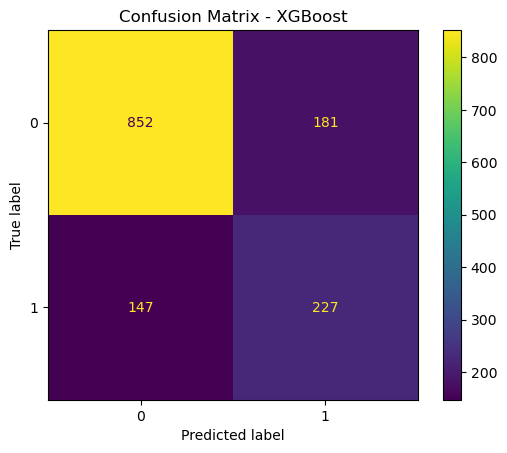

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("Confusion Matrix - XGBoost")
plt.show()


## 📌 Confusion Matrix Insights

- True Positives (227): Correctly identified churn customers  
- False Negatives (147): Missed churn customers (critical issue)  

👉 Reducing false negatives is important to avoid losing customers.

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1033
           1       0.56      0.61      0.58       374

    accuracy                           0.77      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.77      0.77      1407



## 📊 Classification Report Insights

- Accuracy: ~77% → good overall performance  
- Class 0: Strong performance (F1 ~0.84)  
- Class 1: Moderate performance (F1 ~0.58)  

👉 Model is slightly biased toward non-churn customers.

## 📉 ROC Curve Comparison

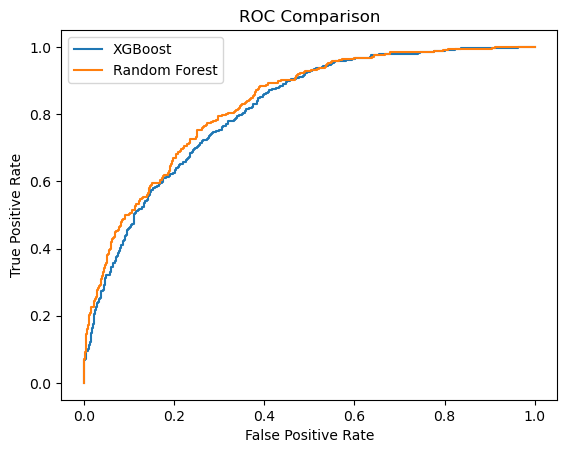

In [16]:
fpr1, tpr1, _ = roc_curve(y_test, xgb_prob)
fpr2, tpr2, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr1, tpr1, label="XGBoost")
plt.plot(fpr2, tpr2, label="Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.show()

## 📊 Feature Importance (XGBoost)

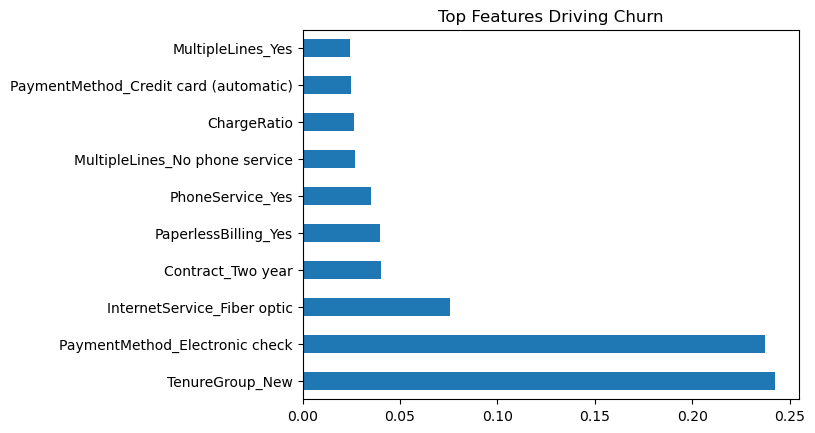

In [17]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Features Driving Churn")
plt.show()

## ⚙️ Feature Engineering

- TenureGroup → captures customer lifecycle  
- ChargeRatio → detects billing behavior  
- ActivityScore → measures engagement  

👉 PaymentMethod_Electronic check and TenureGroup_New are strongest churn indicators.
    
👉 These features help the model learn customer behavior better than raw data.

## 🧠 Explainability (SHAP)

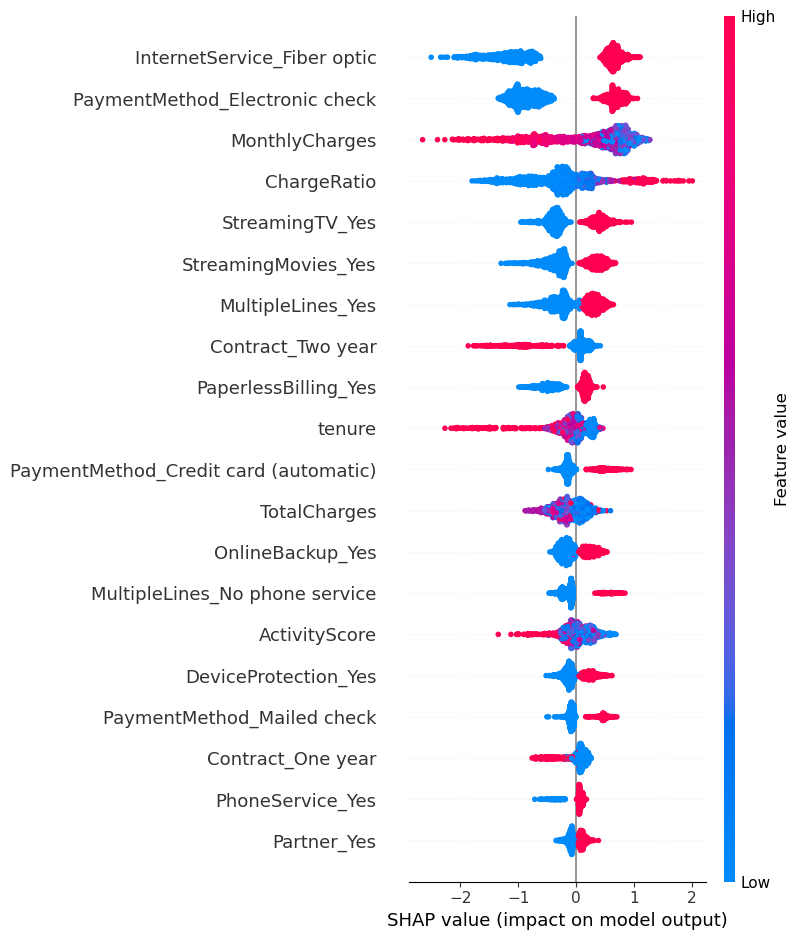

In [18]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## 🧠 SHAP Interpretation (Model Explainability)

The SHAP summary plot shows how each feature impacts the churn prediction.

### 📊 Key Insights:

- **InternetService_Fiber optic**
  → Customers using fiber optic services tend to have higher churn risk  

- **PaymentMethod_Electronic check**
  → Strong indicator of churn; these customers are more likely to leave  

- **MonthlyCharges**
  → Higher monthly charges increase churn probability (price sensitivity)  

- **ChargeRatio**
  → Customers paying more relative to their total usage show higher churn  

- **Contract_Two year**
  → Strong negative impact → long-term contracts reduce churn  

- **tenure**
  → Higher tenure reduces churn → long-term customers are more loyal  

- **PaperlessBilling_Yes**
  → Slight positive contribution to churn  

👉 SHAP confirms that pricing, contract type, and tenure are major drivers of churn.

---

### 🎯 Overall Understanding:

- Customers with **high charges + short tenure + flexible contracts** are at high risk  
- Customers with **long tenure + long-term contracts** are stable  

👉 The model behavior aligns with real-world business patterns, increasing trust in predictions.


## 🧾 Final Conclusion

- XGBoost selected as final model based on stable performance  
- Achieves good accuracy and AUC  
- SHAP explains key churn drivers  

👉 Model is ready for real-world churn prediction and deployment.

## 💼 Business Impact

- Target high-risk customers with personalized offers  
- Promote long-term contracts to reduce churn  
- Monitor pricing strategies for high MonthlyCharges users  

👉 This model helps businesses take proactive retention decisions.

## 💾 Save Model for Deployment

In [20]:
model_path = r"C:\Users\myesw\Downloads\pamgam_project\churn_model.pkl"
columns_path = r"C:\Users\myesw\Downloads\pamgam_project\churn_columns.pkl"

model_path = "model.pkl"
columns_path = "columns.pkl"

pickle.dump(xgb_model, open(model_path, "wb"))
pickle.dump(X.columns, open(columns_path, "wb"))

print("✅ Model Saved Successfully")

✅ Model Saved Successfully
